### 1. ResNet 모델을 불러와 새로운 이미지 데이터셋을 분류하세요. 


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from torchvision import models, datasets
from torchvision.transforms import transforms

import subprocess, logging, warnings
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], capture_output=True)
for font_path in [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf",
]:
    try:
        fm.fontManager.addfont(font_path)
    except Exception:
        pass

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', message='Glyph .* missing from font')

In [5]:
# 데이터셋 불러오기 - CIFAR-10
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

train = datasets.CIFAR10(root='./data',
                         train=True,
                         transform=transform_train,
                         download=True)

test = datasets.CIFAR10(root='./data',
                        train=False,
                        transform=transform_test,
                        download=True)

100%|██████████| 170M/170M [1:42:41<00:00, 27.7kB/s]  


In [ ]:
# 데이터 로더 (batch_size=128)
train_loader = DataLoader(train, batch_size=128, shuffle=True)
test_loader = DataLoader(test, batch_size=128, shuffle=False)

Feature batch shape: torch.Size([128, 3, 32, 32])
Labels batch shape: torch.Size([128])


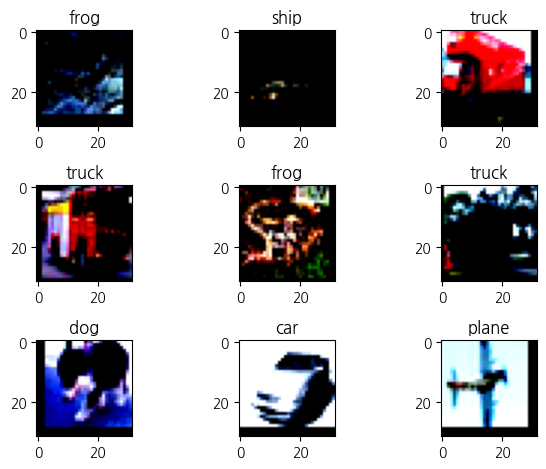

In [7]:
labels_map = {
    0: "plane",
    1: "car",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
# Feature batch shape: torch.Size([64, 3, 32, 32])

print(f"Labels batch shape: {train_labels.size()}")
# Labels batch shape: torch.Size([64])

fig = plt.figure()
for i in range(9):
    train_features, train_labels = next(iter(train_loader))
    ax = fig.add_subplot(3,3, i+1)
    ax.imshow(train_features[0].permute(1,2,0))
    ax.set_title(labels_map[train_labels[0].item()])
plt.tight_layout()
plt.show()

In [ ]:
# pretrained ResNet50 모델 로드
base_model = models.resnet50(weights='IMAGENET1K_V1')

# CIFAR stem: 32px 입력에서 7×7/stride-2 → 3×3/stride-1 교체
base_model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
base_model.maxpool = nn.Identity()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 245MB/s]


In [ ]:
# 전체 freeze 후 conv1(새 가중치) + layer4만 unfreeze
for param in base_model.parameters():
    param.requires_grad = False

for param in base_model.conv1.parameters():
    param.requires_grad = True

for param in base_model.layer4.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in base_model.parameters())
print(f"학습 파라미터: {trainable:,} / 전체: {total:,}")

학습 파라미터: 14,966,464 / 전체: 25,549,352


In [ ]:
class CustomResNet50(nn.Module):
    def __init__(self, num_classes):
        super(CustomResNet50, self).__init__()
        self.model = base_model
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)  # fc는 새 가중치라 학습

    def forward(self, x):
        return self.model(x)

resnet_model = CustomResNet50(num_classes=10)

In [11]:
trainable = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet_model.parameters())
print(f"학습 파라미터: {trainable:,} / 전체: {total:,}")

학습 파라미터: 14,986,954 / 전체: 23,520,842


In [ ]:
import os
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resnet_model = resnet_model.to(device)
print(f"Using device: {device}")

os.makedirs('checkpoints', exist_ok=True)

num_epochs = 30
resnet_losses = []
resnet_val_losses = []
resnet_val_accs = []
best_val_loss = float('inf')
start_time = time.time()

for epoch in range(num_epochs):
    resnet_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    resnet_losses.append(epoch_loss)

    resnet_model.eval()
    correct, total = 0, 0
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet_model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss = val_running_loss / len(test_loader)
    val_acc = correct / total
    resnet_val_losses.append(val_loss)
    resnet_val_accs.append(val_acc)

    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(resnet_model.state_dict(), "checkpoints/resnet_best.pt")

    print(f'Epoch {epoch+1:2d} | Train {epoch_loss:.4f} | Val {val_loss:.4f} | Acc {val_acc*100:.2f}%')

resnet_elapsed = time.time() - start_time
resnet_model.load_state_dict(torch.load("checkpoints/resnet_best.pt"))
print(f"\nBest val loss: {best_val_loss:.4f} 기준 가중치 로드 완료")
print(f"학습 시간: {resnet_elapsed / 60:.1f}분")

Using device: cuda
Epoch  1 | Train 1.1269 | Val 0.8589 | Acc 69.99%
Epoch  2 | Train 0.8007 | Val 0.7502 | Acc 73.98%
Epoch  3 | Train 0.6722 | Val 0.6749 | Acc 76.73%
Epoch  4 | Train 0.5840 | Val 0.6348 | Acc 78.53%
Epoch  5 | Train 0.5165 | Val 0.6028 | Acc 80.23%
Epoch  6 | Train 0.4589 | Val 0.5645 | Acc 81.15%
Epoch  7 | Train 0.4126 | Val 0.5440 | Acc 82.25%
Epoch  8 | Train 0.3654 | Val 0.5268 | Acc 82.72%
Epoch  9 | Train 0.3360 | Val 0.5245 | Acc 83.20%
Epoch 10 | Train 0.3005 | Val 0.5307 | Acc 83.60%
Epoch 11 | Train 0.2665 | Val 0.5232 | Acc 84.22%
Epoch 12 | Train 0.2486 | Val 0.5267 | Acc 84.15%
Epoch 13 | Train 0.2196 | Val 0.5282 | Acc 84.45%
Epoch 14 | Train 0.2011 | Val 0.5284 | Acc 84.81%
Epoch 15 | Train 0.1773 | Val 0.5380 | Acc 85.10%
Epoch 16 | Train 0.1606 | Val 0.5421 | Acc 84.85%
Epoch 17 | Train 0.1399 | Val 0.5622 | Acc 85.19%
Epoch 18 | Train 0.1265 | Val 0.5680 | Acc 84.70%
Epoch 19 | Train 0.1177 | Val 0.5564 | Acc 85.66%
Epoch 20 | Train 0.1043 | Val 0

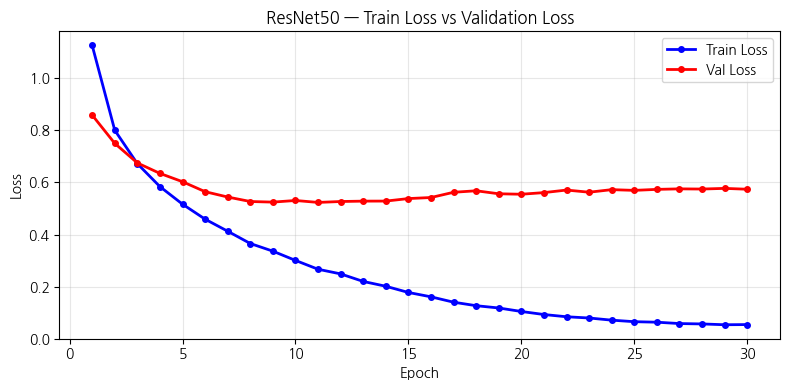

최저 Train Loss: 0.0533 (Epoch 29)
최저 Val Loss:   0.5232 (Epoch 11)


In [14]:
# ResNet50 Train Loss vs Validation Loss
epochs_r = range(1, len(resnet_losses) + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_r, resnet_losses,     'b-o', label='Train Loss', markersize=4, linewidth=2)
ax.plot(epochs_r, resnet_val_losses, 'r-o', label='Val Loss',   markersize=4, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('ResNet50 — Train Loss vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"최저 Train Loss: {min(resnet_losses):.4f} (Epoch {resnet_losses.index(min(resnet_losses))+1})")
print(f"최저 Val Loss:   {min(resnet_val_losses):.4f} (Epoch {resnet_val_losses.index(min(resnet_val_losses))+1})")

In [15]:
resnet_model.eval()
correct = 0
total = 0
class_correct_resnet = [0] * 10
class_total_resnet   = [0] * 10

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet_model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for i in range(len(labels)):
            class_correct_resnet[labels[i]] += (predicted[i] == labels[i]).item()
            class_total_resnet[labels[i]]   += 1

resnet_accuracy = correct / total
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
resnet_class_acc = [
    class_correct_resnet[i] / class_total_resnet[i] if class_total_resnet[i] > 0 else 0
    for i in range(10)
]

print(f'ResNet50 Test Accuracy: {resnet_accuracy * 100:.2f}%')
for cls, acc in zip(classes, resnet_class_acc):
    print(f'  {cls:12s}: {acc*100:.1f}%')

ResNet50 Test Accuracy: 84.22%
  airplane    : 87.5%
  automobile  : 92.4%
  bird        : 79.3%
  cat         : 67.0%
  deer        : 80.7%
  dog         : 78.7%
  frog        : 89.1%
  horse       : 88.0%
  ship        : 90.5%
  truck       : 89.0%


### 2. 이미지 데이터셋과 사전 훈련된 VGG16 모델을 가져와 전이 학습을 수행하세요. 

In [ ]:
# pretrained VGG16 로드
vgg_model = models.vgg16(weights='IMAGENET1K_V1')

# 32px 입력: MaxPool 5개 → 32→1px. 마지막 2개 → Identity로 4×4 feature map 유지
pool_idx = [i for i, m in enumerate(vgg_model.features) if isinstance(m, nn.MaxPool2d)]
for i in pool_idx[-2:]:
    vgg_model.features[i] = nn.Identity()

In [17]:
print(vgg_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# 전체 freeze 후 마지막 conv 블록(block5)만 unfreeze
for param in vgg_model.features.parameters():
    param.requires_grad = False

for layer in list(vgg_model.features.children())[-7:]:
    for param in layer.parameters():
        param.requires_grad = True

vgg_features = vgg_model.features


class CustomVGG16(nn.Module):
    def __init__(self, num_classes):
        super(CustomVGG16, self).__init__()
        self.features = vgg_features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # → (B, 512, 1, 1)
        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


vgg_model = CustomVGG16(num_classes=10)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, vgg_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [ ]:
vgg_model = vgg_model.to(device)

os.makedirs('checkpoints', exist_ok=True)

num_epochs = 30
vgg_losses = []
vgg_val_losses = []
vgg_val_accs = []
best_val_loss = float('inf')
start_time = time.time()

for epoch in range(num_epochs):
    vgg_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    vgg_losses.append(epoch_loss)

    vgg_model.eval()
    correct, total = 0, 0
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss = val_running_loss / len(test_loader)
    val_acc = correct / total
    vgg_val_losses.append(val_loss)
    vgg_val_accs.append(val_acc)

    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(vgg_model.state_dict(), "checkpoints/vgg_best.pt")

    print(f'Epoch {epoch+1:2d} | Train {epoch_loss:.4f} | Val {val_loss:.4f} | Acc {val_acc*100:.2f}%')

vgg_elapsed = time.time() - start_time
vgg_model.load_state_dict(torch.load("checkpoints/vgg_best.pt"))
print(f"\nBest val loss: {best_val_loss:.4f} 기준 가중치 로드 완료")
print(f"학습 시간: {vgg_elapsed / 60:.1f}분")

Epoch  1 | Train 1.0361 | Val 0.7546 | Acc 73.79%
Epoch  2 | Train 0.7380 | Val 0.6722 | Acc 76.62%
Epoch  3 | Train 0.6570 | Val 0.6188 | Acc 78.50%
Epoch  4 | Train 0.6058 | Val 0.5722 | Acc 80.00%
Epoch  5 | Train 0.5691 | Val 0.5594 | Acc 80.23%
Epoch  6 | Train 0.5332 | Val 0.5403 | Acc 81.42%
Epoch  7 | Train 0.5058 | Val 0.5324 | Acc 81.87%
Epoch  8 | Train 0.4828 | Val 0.5348 | Acc 81.83%
Epoch  9 | Train 0.4526 | Val 0.5381 | Acc 81.82%
Epoch 10 | Train 0.4330 | Val 0.5224 | Acc 82.14%
Epoch 11 | Train 0.4150 | Val 0.5271 | Acc 82.24%
Epoch 12 | Train 0.3946 | Val 0.5193 | Acc 82.95%
Epoch 13 | Train 0.3787 | Val 0.5209 | Acc 82.94%
Epoch 14 | Train 0.3587 | Val 0.5349 | Acc 82.91%
Epoch 15 | Train 0.3459 | Val 0.5366 | Acc 82.88%
Epoch 16 | Train 0.3337 | Val 0.5402 | Acc 82.99%
Epoch 17 | Train 0.3186 | Val 0.5134 | Acc 83.35%
Epoch 18 | Train 0.3005 | Val 0.5250 | Acc 83.51%
Epoch 19 | Train 0.2860 | Val 0.5432 | Acc 83.20%
Epoch 20 | Train 0.2751 | Val 0.5563 | Acc 83.08%


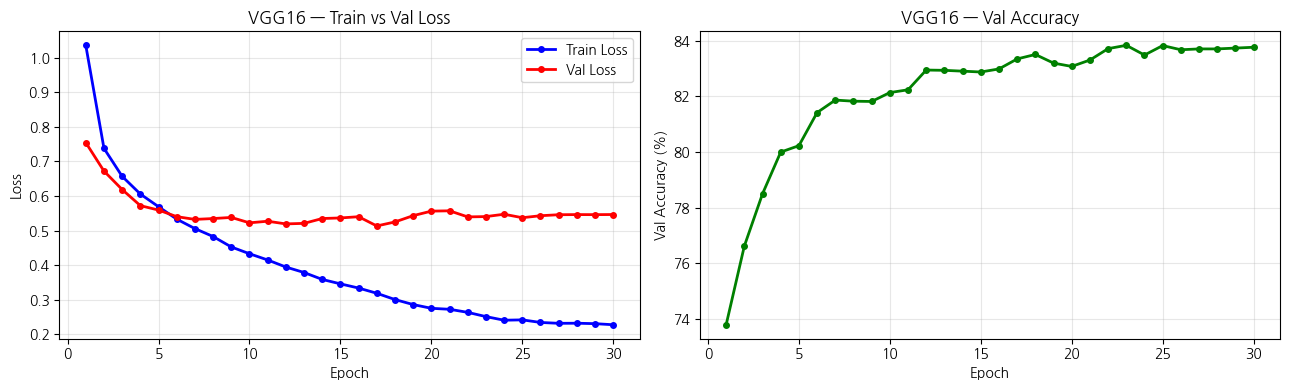

최저 Val Loss: 0.5134 (Epoch 17)
최고 Val Acc:  83.84% (Epoch 23)


In [ ]:
epochs_v = range(1, len(vgg_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 좌: Train / Val Loss
ax1 = axes[0]
ax1.plot(epochs_v, vgg_losses,     'b-o', label='Train Loss', markersize=4, linewidth=2)
ax1.plot(epochs_v, vgg_val_losses, 'r-o', label='Val Loss',   markersize=4, linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('VGG16 — Train vs Val Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# 우: Val Accuracy
ax2 = axes[1]
ax2.plot(epochs_v, [a * 100 for a in vgg_val_accs], 'g-o', markersize=4, linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy (%)')
ax2.set_title('VGG16 — Val Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = vgg_val_losses.index(min(vgg_val_losses)) + 1
print(f"최저 Val Loss: {min(vgg_val_losses):.4f} (Epoch {best_epoch})")
print(f"최고 Val Acc:  {max(vgg_val_accs)*100:.2f}% (Epoch {vgg_val_accs.index(max(vgg_val_accs))+1})")

In [22]:
vgg_model.eval()
correct = 0
total = 0
class_correct_vgg = [0] * 10
class_total_vgg   = [0] * 10

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vgg_model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for i in range(len(labels)):
            class_correct_vgg[labels[i]] += (predicted[i] == labels[i]).item()
            class_total_vgg[labels[i]]   += 1

vgg_accuracy = correct / total
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
vgg_class_acc = [
    class_correct_vgg[i] / class_total_vgg[i] if class_total_vgg[i] > 0 else 0
    for i in range(10)
]

print(f'VGG16 Test Accuracy: {vgg_accuracy * 100:.2f}%')
for cls, acc in zip(classes, vgg_class_acc):
    print(f'  {cls:12s}: {acc*100:.1f}%')

VGG16 Test Accuracy: 83.35%
  airplane    : 84.4%
  automobile  : 92.3%
  bird        : 82.1%
  cat         : 67.1%
  deer        : 79.0%
  dog         : 74.1%
  frog        : 89.1%
  horse       : 85.6%
  ship        : 90.1%
  truck       : 89.7%


### 3. 동일한 데이터셋에서 ResNet과 VGG16을 각각 학습시켜 성능을 비교하세요. 

In [ ]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

r_total, r_train = count_params(resnet_model)
v_total, v_train = count_params(vgg_model)

print(f"{'모델':<12} {'전체 파라미터':>16} {'학습 가능':>16} {'학습 시간':>12}")
print("─" * 60)
print(f"{'ResNet50':<12} {r_total:>16,} {r_train:>16,} {resnet_elapsed/60:>10.1f}분")
print(f"{'VGG16':<12} {v_total:>16,} {v_train:>16,} {vgg_elapsed/60:>10.1f}분")

모델                    전체 파라미터            학습 가능        학습 시간
────────────────────────────────────────────────────────────
ResNet50           23,520,842       14,986,954       18.8분
VGG16              14,982,474        7,347,210       11.4분


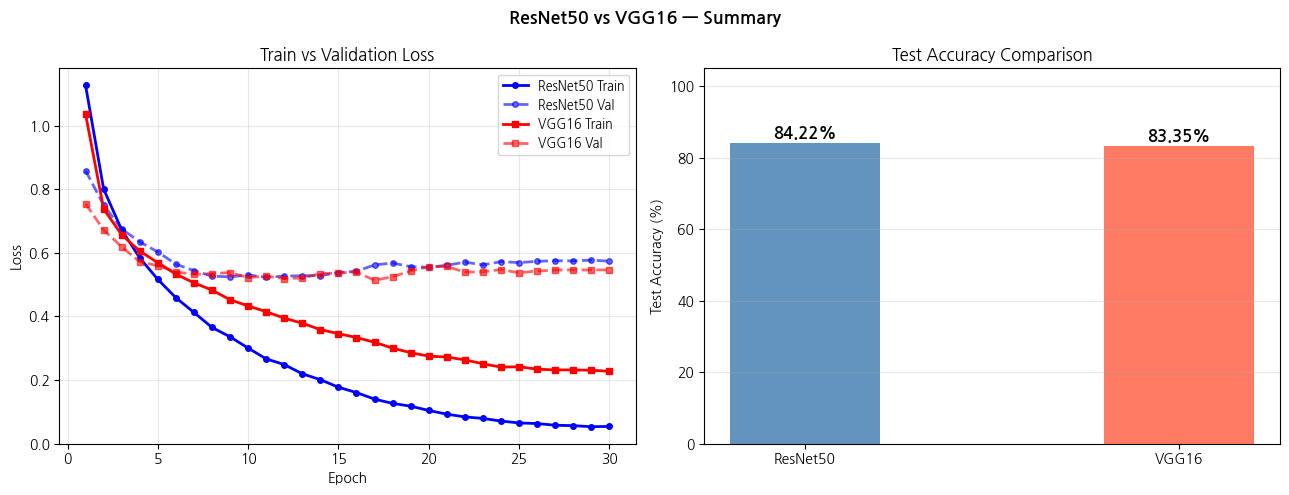


ResNet50: 84.22%  |  VGG16: 83.35%  |  차이: +0.87%p


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 좌: Train(실선) vs Val(점선) Loss — 두 모델 ──
ax1 = axes[0]
ep_r = range(1, len(resnet_losses) + 1)
ep_v = range(1, len(vgg_losses) + 1)
ax1.plot(ep_r, resnet_losses,     'b-o',  label='ResNet50 Train', markersize=4, linewidth=2)
ax1.plot(ep_r, resnet_val_losses, 'b--o', label='ResNet50 Val',   markersize=4, linewidth=2, alpha=0.6)
ax1.plot(ep_v, vgg_losses,        'r-s',  label='VGG16 Train',     markersize=4, linewidth=2)
ax1.plot(ep_v, vgg_val_losses,    'r--s', label='VGG16 Val',       markersize=4, linewidth=2, alpha=0.6)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Train vs Validation Loss')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# ── 우: Test Accuracy ──
ax2 = axes[1]
accs = [resnet_accuracy * 100, vgg_accuracy * 100]
bars = ax2.bar(['ResNet50', 'VGG16'], accs, color=['steelblue', 'tomato'], width=0.4, alpha=0.85)
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 105); ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy Comparison')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('ResNet50 vs VGG16 — Summary', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nResNet50: {resnet_accuracy*100:.2f}%  |  VGG16: {vgg_accuracy*100:.2f}%  |  차이: {(resnet_accuracy-vgg_accuracy)*100:+.2f}%p")

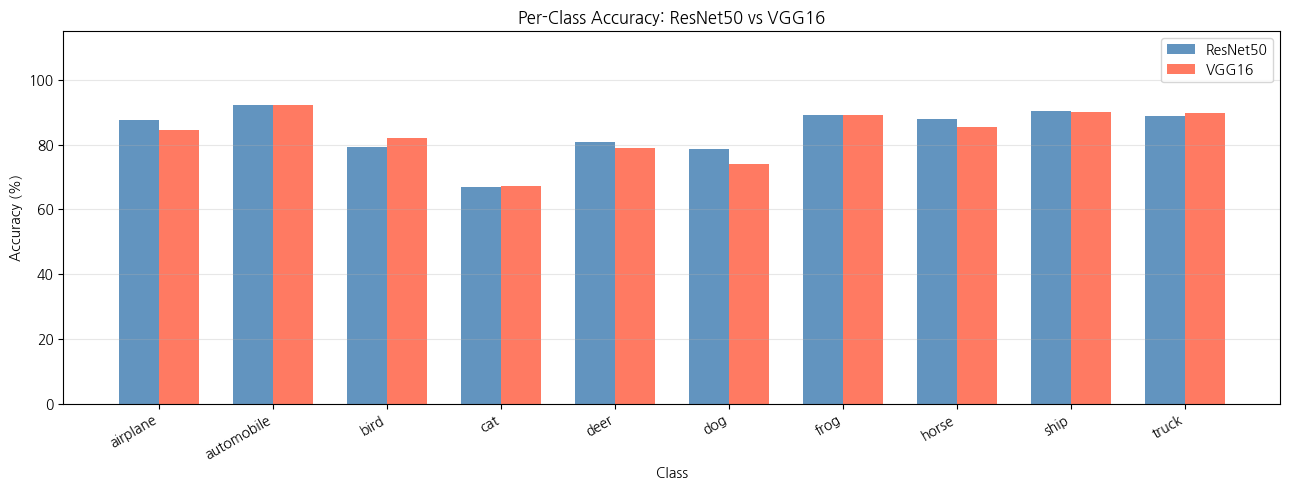


클래스              ResNet50      VGG16    차이(R-V)
────────────────────────────────────────────────
airplane            87.5%      84.4% +    3.1%
automobile          92.4%      92.3% +    0.1%
bird                79.3%      82.1%    -2.8%
cat                 67.0%      67.1%    -0.1%
deer                80.7%      79.0% +    1.7%
dog                 78.7%      74.1% +    4.6%
frog                89.1%      89.1% +    0.0%
horse               88.0%      85.6% +    2.4%
ship                90.5%      90.1% +    0.4%
truck               89.0%      89.7%    -0.7%


In [25]:
# 클래스별 정확도 비교 
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
x_pos = range(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar([i - width/2 for i in x_pos], [a * 100 for a in resnet_class_acc],
       width, label='ResNet50', color='steelblue', alpha=0.85)
ax.bar([i + width/2 for i in x_pos], [a * 100 for a in vgg_class_acc],
       width, label='VGG16', color='tomato', alpha=0.85)
ax.set_xlabel('Class')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy: ResNet50 vs VGG16')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n{'클래스':<14} {'ResNet50':>10} {'VGG16':>10} {'차이(R-V)':>10}")
print("─" * 48)
for cls, r_acc, v_acc in zip(classes, resnet_class_acc, vgg_class_acc):
    diff = (r_acc - v_acc) * 100
    sign = '+' if diff >= 0 else ''
    print(f"{cls:<14} {r_acc*100:>9.1f}% {v_acc*100:>9.1f}% {sign}{diff:>7.1f}%")

### 4. 가상 데이터셋을 생성한 뒤, GridSearch와 RandomSearch 기법으로 하이퍼파라미터 튜닝을 진행하세요.  

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from scipy.stats import randint
import pandas as pd
import seaborn as sns

In [ ]:
# 데이터 준비
X, y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# GridSearch
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model_gs = grid_search.best_estimator_
gs_train_acc = best_model_gs.score(X_train, y_train)
gs_test_acc  = best_model_gs.score(X_test,  y_test)

print('Best params:', grid_search.best_params_)
print(f'Train Accuracy: {gs_train_acc:.4f}  |  Test Accuracy: {gs_test_acc:.4f}')


Best params: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Train Accuracy: 0.9637  |  Test Accuracy: 0.9250


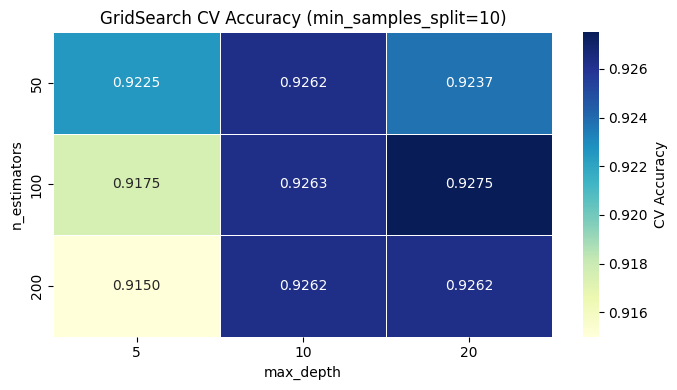

In [ ]:
# GridSearch 결과 히트맵
gs_df = pd.DataFrame(grid_search.cv_results_)
best_split = grid_search.best_params_['min_samples_split']
subset = gs_df[gs_df['param_min_samples_split'] == best_split]
pivot = subset.pivot_table(
    index='param_n_estimators',
    columns='param_max_depth',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CV Accuracy'})
ax.set_title(f'GridSearch CV Accuracy (min_samples_split={best_split})')
ax.set_xlabel('max_depth')
ax.set_ylabel('n_estimators')
plt.tight_layout()
plt.show()


In [ ]:
# RandomSearch
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 25),
    'min_samples_split': randint(2, 20)
}

model = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist,
                                   n_iter=20, cv=5, scoring='accuracy',
                                   random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_rs = random_search.best_estimator_
rs_train_acc = best_model_rs.score(X_train, y_train)
rs_test_acc  = best_model_rs.score(X_test,  y_test)

print('Best params:', random_search.best_params_)
print(f'Train Accuracy: {rs_train_acc:.4f}  |  Test Accuracy: {rs_test_acc:.4f}')


Best params: {'max_depth': 17, 'min_samples_split': 13, 'n_estimators': 104}
Train Accuracy: 0.9500  |  Test Accuracy: 0.9250


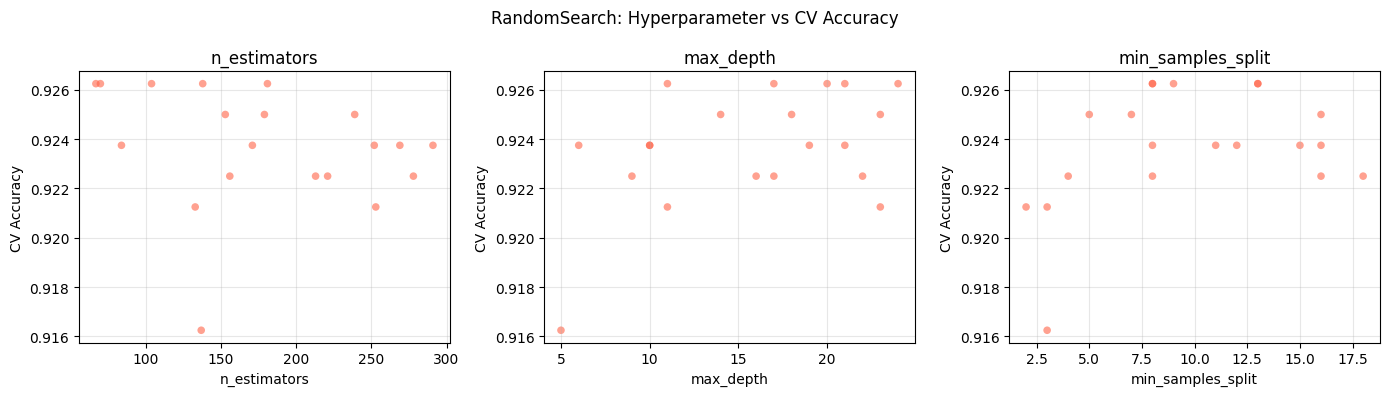

In [ ]:
# RandomSearch: parameter vs CV accuracy
rs_df = pd.DataFrame(random_search.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
param_cols = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split']
labels     = ['n_estimators', 'max_depth', 'min_samples_split']

for ax, col, label in zip(axes, param_cols, labels):
    ax.scatter(rs_df[col].astype(int), rs_df['mean_test_score'],
               alpha=0.6, s=30, color='tomato', edgecolors='none')
    ax.set_xlabel(label)
    ax.set_ylabel('CV Accuracy')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.suptitle('RandomSearch: Hyperparameter vs CV Accuracy', fontsize=12)
plt.tight_layout()
plt.show()


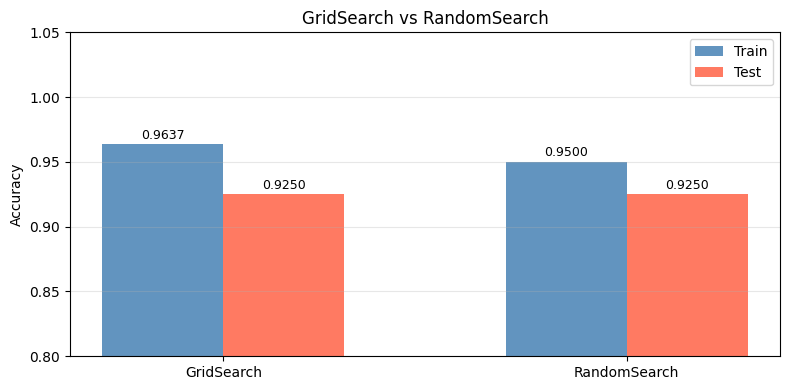

GridSearch   — 탐색 횟수:  27,  Best CV: 0.9275,  Test: 0.9250
RandomSearch — 탐색 횟수:  20,  Best CV: 0.9263,  Test: 0.9250


In [ ]:
# GridSearch vs RandomSearch 최종 비교
fig, ax = plt.subplots(figsize=(8, 4))
methods = ['GridSearch', 'RandomSearch']
train_accs = [gs_train_acc, rs_train_acc]
test_accs  = [gs_test_acc,  rs_test_acc]
x = range(len(methods))
w = 0.3

bars1 = ax.bar([i - w/2 for i in x], train_accs, w, label='Train', color='steelblue', alpha=0.85)
bars2 = ax.bar([i + w/2 for i in x], test_accs,  w, label='Test',  color='tomato',    alpha=0.85)
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(methods)
ax.set_ylim(0.8, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('GridSearch vs RandomSearch')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'GridSearch   — 탐색 횟수: {len(grid_search.cv_results_["params"]):3d},  Best CV: {grid_search.best_score_:.4f},  Test: {gs_test_acc:.4f}')
print(f'RandomSearch — 탐색 횟수: {len(random_search.cv_results_["params"]):3d},  Best CV: {random_search.best_score_:.4f},  Test: {rs_test_acc:.4f}')
